# 03 — Neural Network Built From Scratch (NumPy only)

**Goal:** implement a small feedforward neural network's forward pass, cost function, backward
pass (backpropagation), and gradient descent update **using only NumPy** — no TensorFlow/Keras.

**Why we do this:** anyone can call `model.fit()`. Building it from scratch proves you understand
*what's actually happening* inside — the matrix multiplications, activation functions,
and chain-rule-based gradient computation that every framework does for you automatically. This
notebook is a small deliberate detour before we switch to Keras for the real experiments.

**Architecture:** Input → Hidden layer (ReLU) → Output layer (Sigmoid) → Binary cross-entropy loss.
We'll train it on the **small** tabular subset from Notebook 01 (small, so training is fast in pure
NumPy) and check that the loss decreases and validation accuracy is reasonable.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load data

We reuse the exact same `small` training subset and validation set from Notebook 01, so this
from-scratch model is judged the same way as everything else in the project.

In [2]:
data = joblib.load("../data/processed/tabular_data.joblib")
X_train, y_train = data["subsets"]["small"]
X_val, y_val = data["X_val"], data["y_val"]

# Our from-scratch implementation expects features-as-rows, examples-as-columns (common NN convention)
X_train_T = X_train.T          # shape: (n_features, n_examples)
y_train_T = y_train.reshape(1, -1)
X_val_T = X_val.T
y_val_T = y_val.reshape(1, -1)

n_features = X_train_T.shape[0]
print("n_features:", n_features, " n_examples (train):", X_train_T.shape[1])

n_features: 108  n_examples (train): 800


## 2. Initialize parameters

Weights are initialized small and random (to break symmetry between neurons); biases start at zero.
We use **He initialization** scaling for the ReLU hidden layer.

In [3]:
def initialize_parameters(n_x, n_h, n_y):
    rng = np.random.RandomState(RANDOM_STATE)
    W1 = rng.randn(n_h, n_x) * np.sqrt(2.0 / n_x)   # He initialization for ReLU
    b1 = np.zeros((n_h, 1))
    W2 = rng.randn(n_y, n_h) * np.sqrt(2.0 / n_h)
    b2 = np.zeros((n_y, 1))
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

## 3. Forward propagation

`Z1 = W1 X + b1`, `A1 = ReLU(Z1)`, `Z2 = W2 A1 + b2`, `A2 = sigmoid(Z2)` — `A2` is our predicted
probability of the positive class.

In [4]:
def relu(Z):
    return np.maximum(0, Z)

def sigmoid(Z):
    return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))   # clip avoids overflow warnings

def forward_propagation(X, params):
    W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]
    Z1 = W1 @ X + b1
    A1 = relu(Z1)
    Z2 = W2 @ A1 + b2
    A2 = sigmoid(Z2)
    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache

## 4. Cost function — binary cross-entropy

This is the same loss function logistic regression uses, which is why a single-layer version of
this network would behave very similarly to logistic regression

In [5]:
def compute_cost(A2, Y, params=None, l2_lambda=0.0):
    m = Y.shape[1]
    eps = 1e-8
    cost = -np.sum(Y * np.log(A2 + eps) + (1 - Y) * np.log(1 - A2 + eps)) / m
    if l2_lambda > 0 and params is not None:
        l2_term = (np.sum(params["W1"]**2) + np.sum(params["W2"]**2)) * (l2_lambda / (2 * m))
        cost += l2_term
    return float(np.squeeze(cost))

## 5. Backward propagation

Manually applying the chain rule to get gradients of the cost with respect to every parameter.
This is the part that frameworks like TensorFlow normally do for you with automatic
differentiation — implementing it by hand is the whole point of this notebook.

In [6]:
def backward_propagation(params, cache, X, Y, l2_lambda=0.0):
    m = X.shape[1]
    W1, W2 = params["W1"], params["W2"]
    A1, A2 = cache["A1"], cache["A2"]

    dZ2 = A2 - Y                                  # derivative of BCE loss w.r.t. Z2 (sigmoid output)
    dW2 = (dZ2 @ A1.T) / m + (l2_lambda / m) * W2
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m

    dA1 = W2.T @ dZ2
    dZ1 = dA1 * (cache["Z1"] > 0)                 # ReLU derivative: 1 where Z1>0 else 0
    dW1 = (dZ1 @ X.T) / m + (l2_lambda / m) * W1
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

def update_parameters(params, grads, learning_rate):
    params["W1"] -= learning_rate * grads["dW1"]
    params["b1"] -= learning_rate * grads["db1"]
    params["W2"] -= learning_rate * grads["dW2"]
    params["b2"] -= learning_rate * grads["db2"]
    return params

## 6. Put it all together: training loop (batch gradient descent)

In [7]:
def train_nn_from_scratch(X, Y, n_h=16, epochs=2000, learning_rate=0.05, l2_lambda=0.01, print_every=200):
    n_x = X.shape[0]
    n_y = 1
    params = initialize_parameters(n_x, n_h, n_y)
    costs = []
    for i in range(epochs):
        A2, cache = forward_propagation(X, params)
        cost = compute_cost(A2, Y, params, l2_lambda)
        grads = backward_propagation(params, cache, X, Y, l2_lambda)
        params = update_parameters(params, grads, learning_rate)
        if i % print_every == 0:
            costs.append(cost)
            print(f"epoch {i:5d} | cost {cost:.4f}")
    return params, costs

def predict(X, params, threshold=0.5):
    A2, _ = forward_propagation(X, params)
    return (A2 > threshold).astype(int)

## 7. Train on the `small` subset and check it actually learns

epoch     0 | cost 0.6801
epoch   200 | cost 0.3309
epoch   400 | cost 0.3058
epoch   600 | cost 0.2914
epoch   800 | cost 0.2810
epoch  1000 | cost 0.2728
epoch  1200 | cost 0.2659
epoch  1400 | cost 0.2598
epoch  1600 | cost 0.2544
epoch  1800 | cost 0.2494


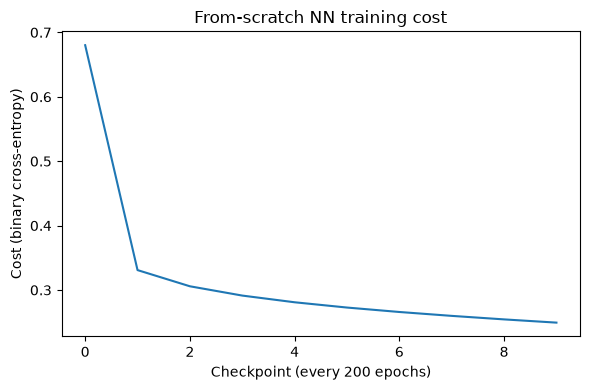

In [8]:
params, costs = train_nn_from_scratch(
    X_train_T, y_train_T, n_h=16, epochs=2000, learning_rate=0.05, l2_lambda=0.01
)

plt.figure(figsize=(6,4))
plt.plot(costs)
plt.xlabel("Checkpoint (every 200 epochs)")
plt.ylabel("Cost (binary cross-entropy)")
plt.title("From-scratch NN training cost")
plt.tight_layout()
plt.savefig("../results/figures/scratch_nn_cost_curve.png", dpi=150)
plt.show()

In [9]:
from sklearn.metrics import accuracy_score, f1_score

train_preds = predict(X_train_T, params)
val_preds = predict(X_val_T, params)

print("Train accuracy:", accuracy_score(y_train_T.ravel(), train_preds.ravel()))
print("Val accuracy:  ", accuracy_score(y_val_T.ravel(), val_preds.ravel()))
print("Val F1:        ", f1_score(y_val_T.ravel(), val_preds.ravel()))

Train accuracy: 0.89625
Val accuracy:   0.8350163755458515
Val F1:         0.6258124419684308


## 8. Sanity check against scikit-learn's `MLPClassifier`

We're not comparing this to the main project results — just confirming our hand-written
implementation is *correct* (learns something sensible) by comparing to a trusted library
implementation on the exact same small subset.

In [10]:
from sklearn.neural_network import MLPClassifier

sk_mlp = MLPClassifier(hidden_layer_sizes=(16,), activation="relu", alpha=0.01,
                        max_iter=2000, random_state=RANDOM_STATE)
sk_mlp.fit(X_train, y_train)
print("sklearn MLP val accuracy:", sk_mlp.score(X_val, y_val))
print("Our from-scratch NN val accuracy:", accuracy_score(y_val_T.ravel(), val_preds.ravel()))
print("(These should be in the same ballpark — exact match isn't expected due to different "
      "initialization, optimizer, and training details.)")

sklearn MLP val accuracy: 0.8123635371179039
Our from-scratch NN val accuracy: 0.8350163755458515
(These should be in the same ballpark — exact match isn't expected due to different initialization, optimizer, and training details.)


## Summary

We implemented forward propagation, binary cross-entropy loss, backpropagation, and gradient
descent by hand, trained it on real data, and confirmed it learns a sensible decision boundary
(comparable accuracy to a trusted library implementation).